# OmniLearn Embedding Visualisations

**Visualising what the OmniLearn foundation model "sees" in the SLD events,
side-by-side with other particle-physics datasets.**

The end-to-end pipeline before this notebook is run:

1. **`sld-resurrect download-checkpoints`** -- fetch pretrained `s/m/l`
   OmniLearn checkpoints.
2. **`sld-resurrect process-dataset {jetclass1, h1, aleph, sld}`** -- convert
   each raw dataset into the fixed-size $(\Delta\eta, \Delta\phi, \log p_T,
   \log E)$ point clouds OmniLearn consumes.
3. **`sld-resurrect inference --task embed`** -- run each point cloud through
   a pretrained checkpoint and save the body embeddings.
4. **`sld-resurrect reduce-embeddings`** -- mean-pool over the token axis,
   apply standard-scaling + 50-component PCA, then run t-SNE / UMAP down to
   2 dimensions. The 2D coordinates land in
   `{$SLD_BASE}/omnilearned/reduced/reduced_{tsne,umap}_{s,m,l}.h5`.

This notebook consumes those last files and produces the publication
plots.

---
## 1. Imports and paths

In [10]:
import os
import h5py
import numpy as np
import pandas as pd

from quickstats.plots import Embedding2DPlot


OMNILEARN_REDUCED_DIR = "/global/cfs/cdirs/m5115/SLD/omnilearned/reduced"
PLOTS_DIR = "/global/cfs/cdirs/m5115/SLD/analysis/plots"

if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)


---
## 2. Loading the reduced embeddings

In [11]:
def load_reduced(path: Path) -> dict[str, np.ndarray]:
    """Load all top-level datasets from a reduced-embedding HDF5 file."""
    with h5py.File(path, "r") as f:
        return {key: f[key][:] for key in f}


def reduced_path(method: str, size: str) -> str:
    """Return the conventional reduced-output path for ``(method, size)``."""
    return os.path.join(OMNILEARN_REDUCED_DIR, f"reduced_{method}_{size}.h5")


## 4. Embedding Visualization

### 4.1 Plot styling and channel labels

In [12]:
LABEL_MAP: dict[str, str] = {
    'aleph_LEP1MCZQQ94YMCE1994_boosted_frame':
        r'ALEPH $Z \rightarrow q\bar{q}$ (boosted frame)',
    'aleph_LEP1MCZQQ94YMCE1994_hemisphere_leading':
        r'ALEPH $Z \rightarrow q\bar{q}$ (leading jet)',
    'aleph_LEP1MCZQQ94YMCE1994_hemisphere_subleading':
        r'ALEPH $Z \rightarrow q\bar{q}$ (subleading jet)',
    'aleph_LEP1MCZQQ94YMCE1994_superjet':
        r'ALEPH $Z \rightarrow q\bar{q}$ (super jet)',
    'h1_Django_Eminus06':
        r'H1 DIS $e^- p \rightarrow e^- X$',
    'h1_Django_Eplus0607':
        r'H1 DIS $e^+ p \rightarrow e^+ X$',
    'jetclass1_ZToQQ':
        r'JetClass $Z \rightarrow q\bar{q}$',
    'sld_boosted_frame':
        r'SLD $Z \rightarrow q\bar{q}$ (boosted frame)',
    'sld_hemisphere_leading':
        r'SLD $Z \rightarrow q\bar{q}$ (leading jet)',
    'sld_hemisphere_subleading':
        r'SLD $Z \rightarrow q\bar{q}$ (subleading jet)',
    'sld_superjet':
        r'SLD $Z \rightarrow q\bar{q}$ (super jet)',
}

PLOT_STYLES = {
    'legend': {
        'fontsize': 15,
        'facecolor': 'white',
        'framealpha': 1,
        'frameon': True,
        'edgecolor': 'none',
    },
    'scatter': {
        'alpha': 0.5,
        's': 12,
        'rasterized': False,
    },
    'axis': {'labelsize': 18},
    'xlabel': {'loc': 'center', 'fontsize': 18},
    'ylabel': {'loc': 'center', 'fontsize': 18},
}

# The default channel selection used in the publication figure: the
# four hemisphere-strategy SLD/ALEPH variants plus the cross-experiment
# reference points. Edit this list to focus the plot on a different
# slice -- e.g. all four SLD strategies for an internal sanity check.
DEFAULT_CHANNELS: tuple[str, ...] = (
    'sld_hemisphere_leading',
    'sld_hemisphere_subleading',
    'aleph_LEP1MCZQQ94YMCE1994_hemisphere_leading',
    'aleph_LEP1MCZQQ94YMCE1994_hemisphere_subleading',
    'jetclass1_ZToQQ',
    'h1_Django_Eminus06',
    'h1_Django_Eplus0607',
)


In [17]:
def make_embedding_plot(
    method: str,
    size: str,
    channels: tuple[str, ...] = DEFAULT_CHANNELS,
    save: bool = True,
) -> Embedding2DPlot:
    """Load the reduced file, draw, optionally save, return the plotter."""
    path = reduced_path(method, size)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found. Run "
            f"`sld-resurrect reduce-embeddings --method {method} --size {size}` "
            f"first."
        )

    data = load_reduced(path)
    available = sorted(data.keys())
    missing = [c for c in channels if c not in data]
    if missing:
        raise KeyError(
            f"Channels not found in {path.name}: {missing!r}\n"
            f"Available: {available!r}"
        )

    plotter = Embedding2DPlot(
        data, label_map=LABEL_MAP, styles=PLOT_STYLES,
    )
    plotter.draw(classes=list(channels))

    if save:
        out = os.path.join(PLOTS_DIR, f"embedding_{method}_{size}.pdf")
        plotter.figure.savefig(out, bbox_inches='tight')
        print(f"  saved {out}")

    return plotter


  saved /global/cfs/cdirs/m5115/SLD/analysis/plots/embedding_tsne_m.pdf


<Figure size 640x480 with 0 Axes>

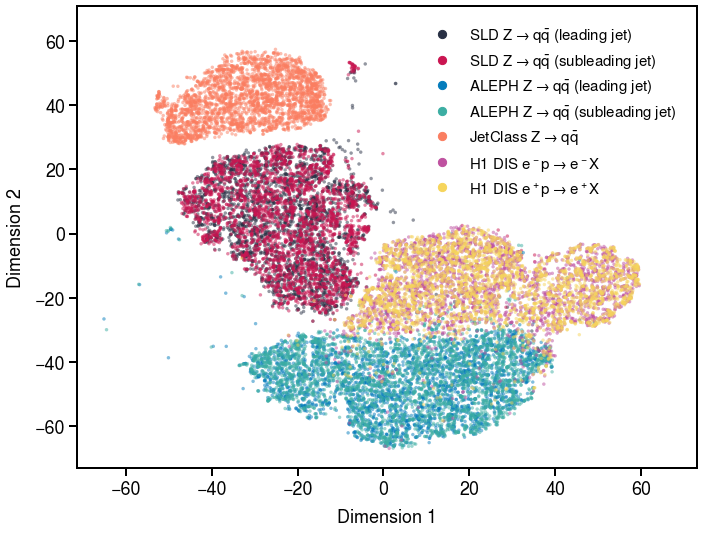

In [18]:
make_embedding_plot('tsne', 'm')